# 00 — Introduction: Housing Equity in London and the Case of Southwark

This notebook establishes the analytical context for the study.  
It situates Southwark within the broader London housing landscape and justifies its selection as the primary case study borough.

**Sections**
1. London Housing Context — city-wide price trends and spatial inequality
2. Why Southwark? — borough profile and positioning relative to London
3. Research Framework — five research questions and methodological overview
4. Data Sources — inventory and spatial coverage

## Section 1 — London Housing Context

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import geopandas as gpd
import glob

warnings.filterwarnings('ignore')

BASE     = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE, 'data')
FIG_DIR  = os.path.join(BASE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('✓ Imports OK')

✓ Imports OK


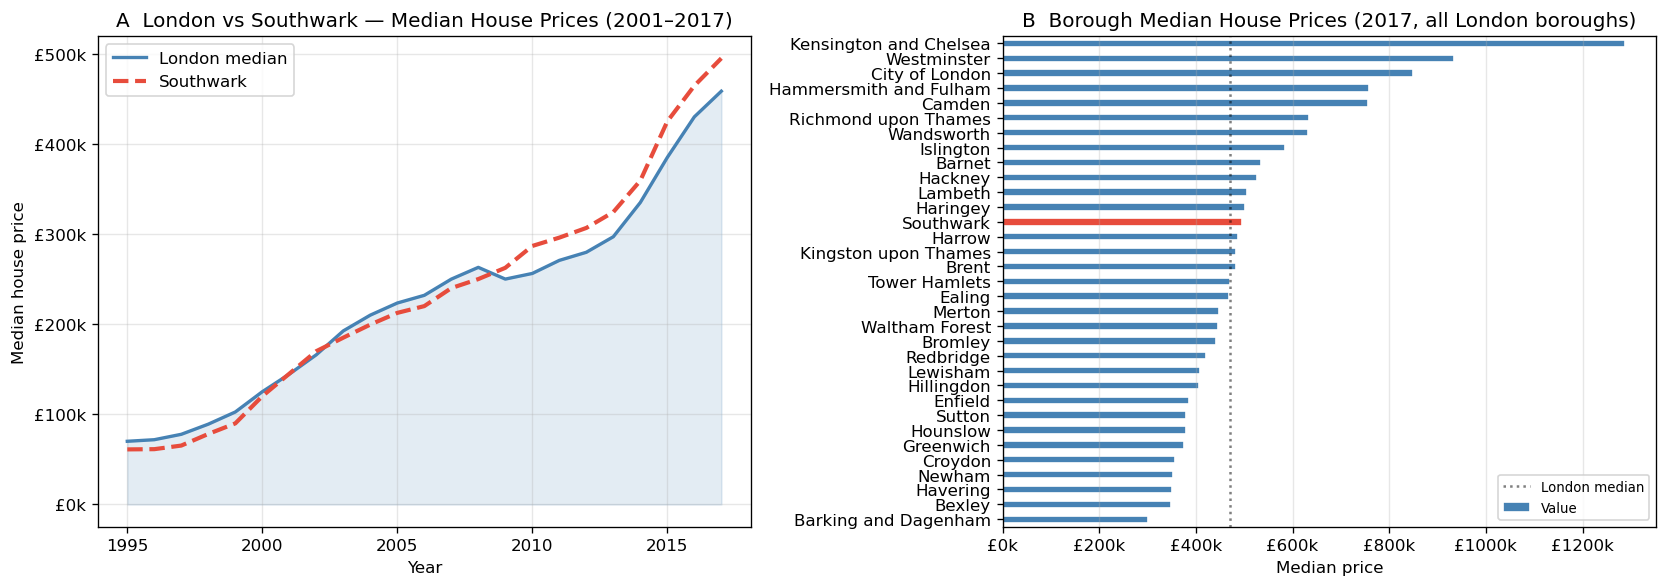

Southwark 2017 median: £495,000  |  London median: £470,000
Southwark rank: 13 / 33 (most expensive = 1)


In [2]:
# --- 1.1  London-wide house price trends (Land Registry, LSOA medians) -------
lr = pd.read_csv(os.path.join(DATA_DIR, 'land_registry_house_prices_LSOA.csv'),
                 low_memory=False)
lr = lr[lr['Measure'] == 'Median'].copy()
lr['Value']    = pd.to_numeric(lr['Value'], errors='coerce')
lr['year_num'] = lr['Year'].str.extract(r'(\d{4})').astype(float)
lr['borough']  = lr['Area'].str.extract(r'^(.+?)\s+\d')

# Annual median by borough and London-wide
london_trend   = lr.groupby('year_num')['Value'].median().reset_index()
southwark_trend = lr[lr['borough'] == 'Southwark'].groupby('year_num')['Value'].median().reset_index()

# Select key boroughs for comparison (mix of inner/outer, deprived/affluent)
COMPARE_BOROUGHS = ['Kensington and Chelsea', 'Westminster', 'Hackney',
                    'Southwark', 'Lewisham', 'Tower Hamlets', 'Barking and Dagenham']
borough_trends = {}
for b in COMPARE_BOROUGHS:
    t = lr[lr['borough'] == b].groupby('year_num')['Value'].median()
    if len(t) > 5:
        borough_trends[b] = t

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: London median + Southwark overlay
ax = axes[0]
ax.fill_between(london_trend['year_num'], london_trend['Value'] / 1000,
                alpha=0.15, color='steelblue', label='_nolegend_')
ax.plot(london_trend['year_num'], london_trend['Value'] / 1000,
        color='steelblue', linewidth=2, label='London median')
ax.plot(southwark_trend['year_num'], southwark_trend['Value'] / 1000,
        color='#e74c3c', linewidth=2.5, linestyle='--', label='Southwark')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
ax.set_xlabel('Year'); ax.set_ylabel('Median house price')
ax.set_title('A  London vs Southwark — Median House Prices (2001–2017)')
ax.legend(); ax.grid(alpha=0.3)

# Panel B: Southwark vs selected boroughs (2017)
ax = axes[1]
latest = lr[lr['year_num'] == 2017]
b_latest = latest.groupby('borough')['Value'].median().dropna().sort_values(ascending=True)
# Highlight Southwark
colors = ['#e74c3c' if b == 'Southwark' else 'steelblue' for b in b_latest.index]
b_latest.div(1000).plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
ax.set_title('B  Borough Median House Prices (2017, all London boroughs)')
ax.set_xlabel('Median price'); ax.set_ylabel('')
ax.axvline(b_latest.median() / 1000, color='black', linestyle=':', alpha=0.5, label='London median')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'intro_london_price_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

swk_price = b_latest.get('Southwark', None)
london_med = b_latest.median()
print(f'Southwark 2017 median: £{swk_price:,.0f}  |  London median: £{london_med:,.0f}')
print(f'Southwark rank: {sorted(b_latest.values, reverse=True).index(swk_price)+1} / {len(b_latest)} (most expensive = 1)')

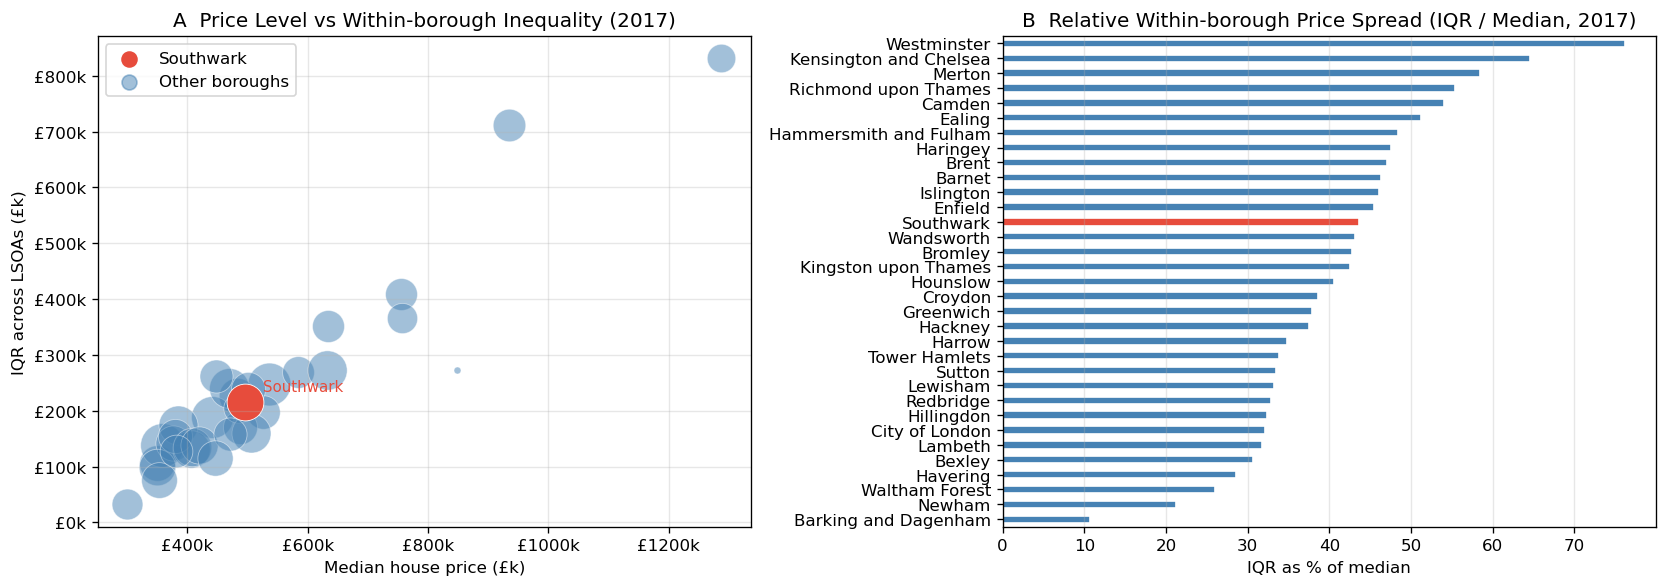

Southwark within-borough spread: 43.6% of median  (rank 13/33)


In [3]:
# --- 1.2  Intra-borough inequality: price spread within Southwark vs London --
# For each borough, compute IQR of LSOA medians (2017) as spread measure
latest17 = lr[lr['year_num'] == 2017].copy()
borough_iqr = latest17.groupby('borough')['Value'].agg(
    Q25=lambda x: x.quantile(0.25),
    Q75=lambda x: x.quantile(0.75),
    median='median',
    n='count'
).dropna()
borough_iqr['IQR'] = borough_iqr['Q75'] - borough_iqr['Q25']
borough_iqr['IQR_pct'] = borough_iqr['IQR'] / borough_iqr['median'] * 100  # relative spread

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: IQR scatter vs median (bubble = n LSOAs)
ax = axes[0]
for _, row in borough_iqr.iterrows():
    color = '#e74c3c' if row.name == 'Southwark' else 'steelblue'
    alpha = 1.0 if row.name == 'Southwark' else 0.5
    ax.scatter(row['median'] / 1000, row['IQR'] / 1000,
               s=row['n'] * 0.8, color=color, alpha=alpha, edgecolors='white', linewidth=0.5)

ax.scatter([], [], s=80, color='#e74c3c', label='Southwark')
ax.scatter([], [], s=80, color='steelblue', alpha=0.5, label='Other boroughs')
ax.set_xlabel('Median house price (£k)')
ax.set_ylabel('IQR across LSOAs (£k)')
ax.set_title('A  Price Level vs Within-borough Inequality (2017)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
ax.legend(); ax.grid(alpha=0.3)

# Annotate Southwark
swk = borough_iqr.loc['Southwark'] if 'Southwark' in borough_iqr.index else None
if swk is not None:
    ax.annotate('Southwark', xy=(swk['median']/1000, swk['IQR']/1000),
                xytext=(swk['median']/1000 + 30, swk['IQR']/1000 + 20),
                arrowprops=dict(arrowstyle='->', color='#e74c3c'), fontsize=9, color='#e74c3c')

# Panel B: Relative IQR ranking
ax = axes[1]
rel_iqr = borough_iqr['IQR_pct'].sort_values(ascending=True)
colors_b = ['#e74c3c' if b == 'Southwark' else 'steelblue' for b in rel_iqr.index]
rel_iqr.plot(kind='barh', ax=ax, color=colors_b, edgecolor='white')
ax.set_title('B  Relative Within-borough Price Spread (IQR / Median, 2017)')
ax.set_xlabel('IQR as % of median'); ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'intro_intraborough_inequality.png'), dpi=150, bbox_inches='tight')
plt.show()

if swk is not None:
    rank_iqr = sorted(rel_iqr.values, reverse=True).index(rel_iqr.get('Southwark', 0)) + 1
    print(f'Southwark within-borough spread: {swk["IQR_pct"]:.1f}% of median  (rank {rank_iqr}/{len(rel_iqr)})')

## Section 2 — Why Southwark?

Southwark is selected as the case study borough for four structural reasons:

1. **Extreme internal heterogeneity**: the borough contains both some of London's wealthiest riverside LSOAs (London Bridge, Bermondsey) and highly deprived estates (Peckham, Nunhead), making it a natural laboratory for within-borough equity analysis.
2. **Active gentrification frontier**: post-2010 regeneration along the South Bank and around Canada Water has accelerated spatial polarisation, placing housing equity pressures on existing lower-income communities.
3. **Demographic diversity**: Southwark is among the most ethnically diverse boroughs, with large shares of lone-parent households, social renters and recent migrants — groups disproportionately exposed to housing stress.
4. **Data richness**: high EPC registration density, complete transport accessibility coverage (PTAI), and full Census 2021 LSOA granularity enable robust multi-dimensional index construction.

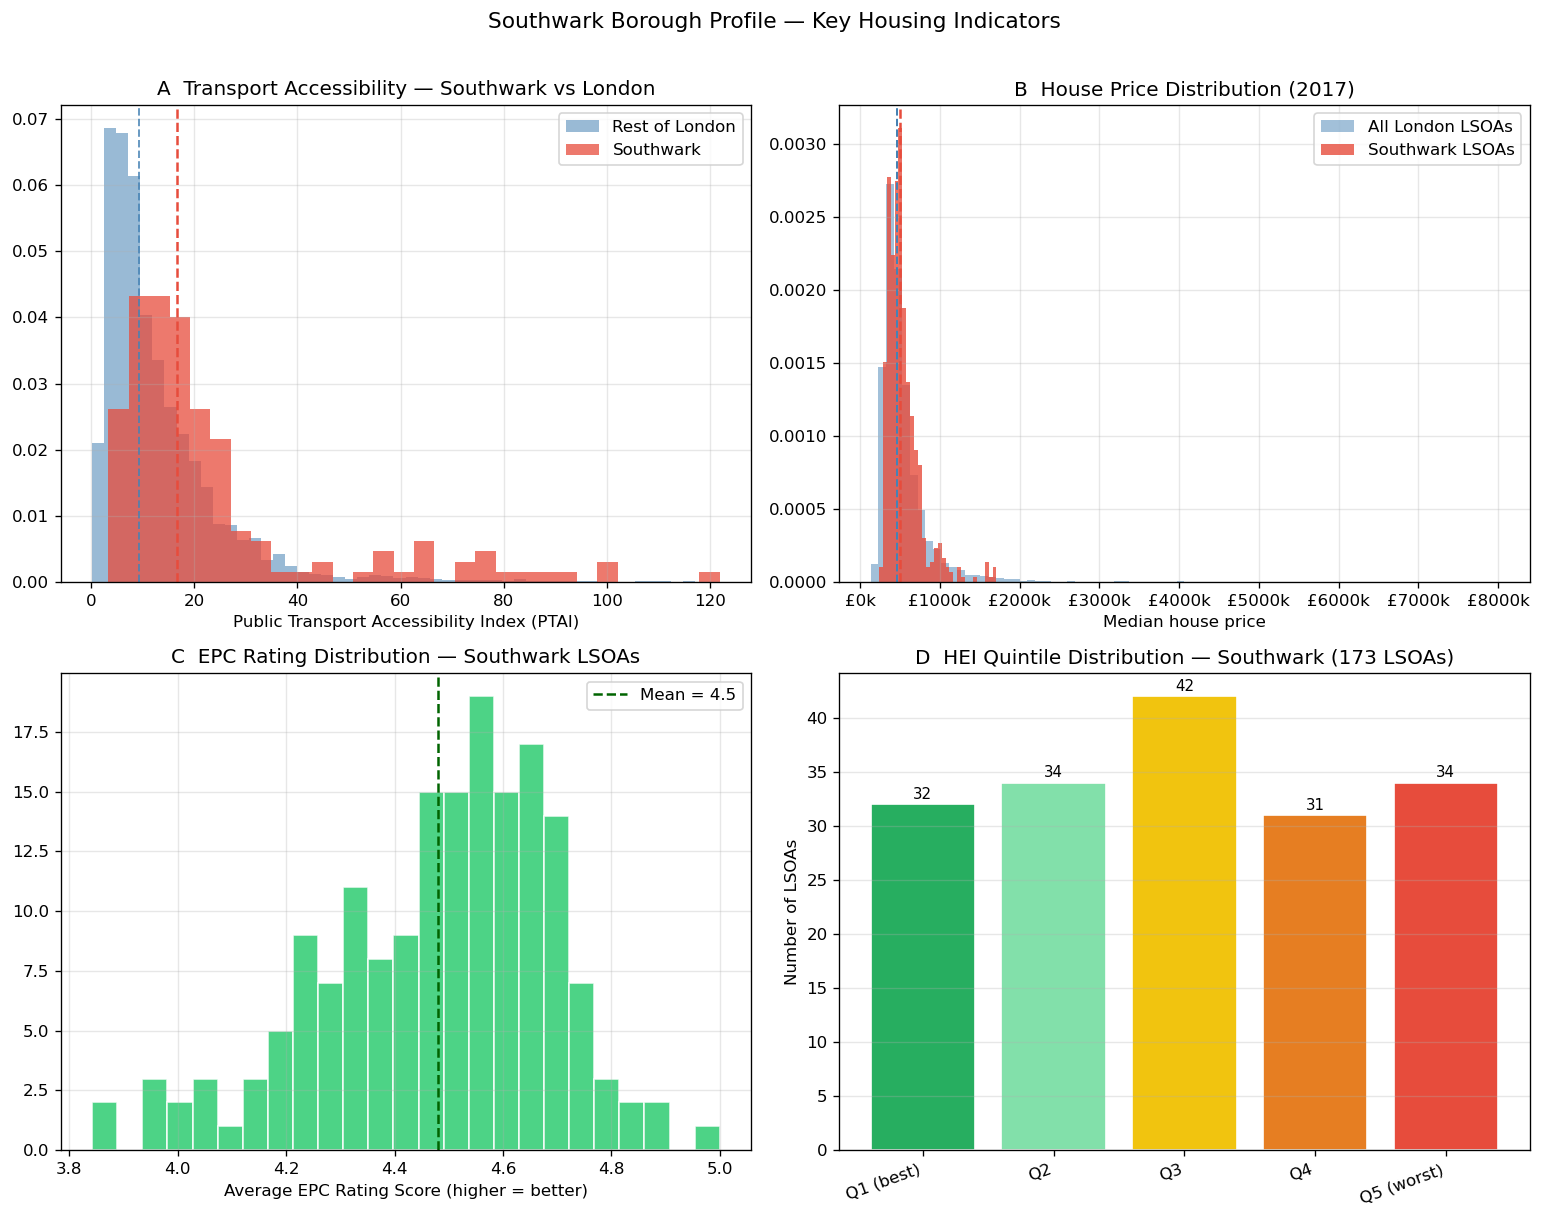

Southwark PTAI mean: 23.79  |  London mean: 13.34
Southwark above London transport mean: 64% of LSOAs


In [4]:
# --- 2.1  Southwark profile: transport, healthcare, EPC, house price ----------
hei = pd.read_csv(os.path.join(DATA_DIR, 'master_southwark_hei.csv'))
hei = hei.drop_duplicates(subset=['lsoa21cd']).copy()

transport_all = pd.read_csv(os.path.join(DATA_DIR, 'transport_accessibility_LSOA2011.csv'))
swk_lsoa = set(hei['lsoa11cd'].dropna())
transport_swk = transport_all[transport_all['LSOA2011'].isin(swk_lsoa)]
transport_oth = transport_all[~transport_all['LSOA2011'].isin(swk_lsoa)]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel A: Transport PTAI — Southwark vs rest of London
ax = axes[0, 0]
ax.hist(transport_oth['AvPTAI2015'].dropna(), bins=50, alpha=0.55,
        color='steelblue', density=True, label='Rest of London')
ax.hist(transport_swk['AvPTAI2015'].dropna(), bins=30, alpha=0.75,
        color='#e74c3c', density=True, label='Southwark')
ax.axvline(transport_oth['AvPTAI2015'].median(), color='steelblue',
           linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(transport_swk['AvPTAI2015'].median(), color='#e74c3c',
           linestyle='--', linewidth=1.5)
ax.set_xlabel('Public Transport Accessibility Index (PTAI)')
ax.set_title('A  Transport Accessibility — Southwark vs London')
ax.legend(); ax.grid(alpha=0.3)

# Panel B: House price distribution
ax = axes[0, 1]
london_prices = lr[lr['year_num'] == 2017]['Value'].dropna()
swk_prices    = lr[(lr['year_num'] == 2017) & (lr['borough'] == 'Southwark')]['Value'].dropna()
ax.hist(london_prices / 1000, bins=80, alpha=0.5, color='steelblue',
        density=True, label='All London LSOAs')
ax.hist(swk_prices / 1000, bins=30, alpha=0.8, color='#e74c3c',
        density=True, label='Southwark LSOAs')
ax.axvline(london_prices.median() / 1000, color='steelblue', linestyle='--', linewidth=1.2)
ax.axvline(swk_prices.median() / 1000, color='#e74c3c', linestyle='--', linewidth=1.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
ax.set_xlabel('Median house price'); ax.set_title('B  House Price Distribution (2017)')
ax.legend(); ax.grid(alpha=0.3)

# Panel C: EPC rating distribution within Southwark
ax = axes[1, 0]
epc_dist = hei['avg_epc_rating_num'].dropna()
ax.hist(epc_dist, bins=25, color='#2ecc71', edgecolor='white', alpha=0.85)
ax.axvline(epc_dist.mean(), color='darkgreen', linestyle='--', linewidth=1.5,
           label=f'Mean = {epc_dist.mean():.1f}')
ax.set_xlabel('Average EPC Rating Score (higher = better)')
ax.set_title('C  EPC Rating Distribution — Southwark LSOAs')
ax.legend(); ax.grid(alpha=0.3)

# Panel D: HEI quintile spatial distribution summary
ax = axes[1, 1]
q_counts = hei['HEI_quintile'].value_counts().reindex(
    ['Q1 (best)', 'Q2', 'Q3', 'Q4', 'Q5 (worst)'])
QCOLORS = ['#27ae60', '#82e0aa', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(q_counts.index, q_counts.values, color=QCOLORS, edgecolor='white')
for bar, val in zip(bars, q_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=9)
ax.set_ylabel('Number of LSOAs')
ax.set_title('D  HEI Quintile Distribution — Southwark (173 LSOAs)')
ax.set_xticklabels(q_counts.index, rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Southwark Borough Profile — Key Housing Indicators', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'intro_southwark_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Southwark PTAI mean: {transport_swk["AvPTAI2015"].mean():.2f}  |  London mean: {transport_all["AvPTAI2015"].mean():.2f}')
print(f'Southwark above London transport mean: {(transport_swk["AvPTAI2015"] > transport_all["AvPTAI2015"].mean()).mean()*100:.0f}% of LSOAs')

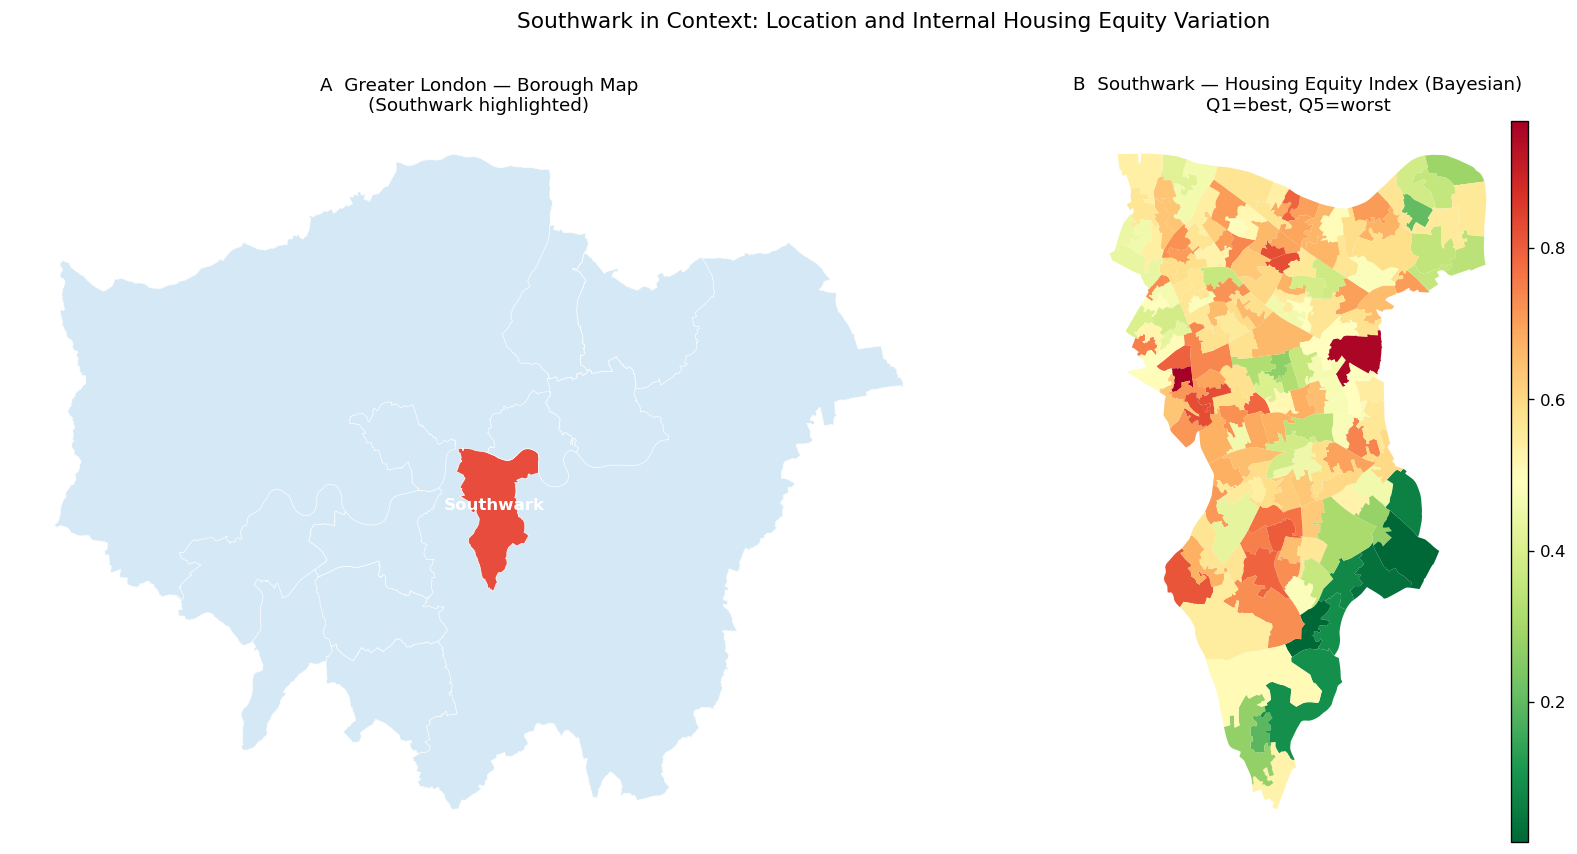

In [5]:
# --- 2.2  Spatial map: Southwark within Greater London -----------------------
SHP_DIR   = os.path.join(BASE, 'LSOA_Shapfile')
shp_files = glob.glob(os.path.join(SHP_DIR, '*.shp'))

# Load all borough shapefiles and label Southwark
all_gdfs = []
for shp in shp_files:
    try:
        gdf = gpd.read_file(shp).to_crs(epsg=27700)
        fname = os.path.splitext(os.path.basename(shp))[0]
        gdf['borough'] = fname
        all_gdfs.append(gdf[['geometry', 'borough']])
    except Exception:
        pass

london_gdf = pd.concat(all_gdfs, ignore_index=True)

# Dissolve to borough boundaries
borough_gdf = london_gdf.dissolve(by='borough').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel A: Greater London map — highlight Southwark
ax = axes[0]
for _, row in borough_gdf.iterrows():
    color  = '#e74c3c' if row['borough'] == 'Southwark' else '#d5e8f5'
    edge   = 'white'
    lw     = 0.4
    borough_gdf[borough_gdf['borough'] == row['borough']].plot(
        ax=ax, color=color, edgecolor=edge, linewidth=lw)

# Label Southwark
swk_geom = borough_gdf[borough_gdf['borough'] == 'Southwark']
if len(swk_geom):
    cx = swk_geom.geometry.centroid.iloc[0].x
    cy = swk_geom.geometry.centroid.iloc[0].y
    ax.annotate('Southwark', xy=(cx, cy), fontsize=10, fontweight='bold',
                color='white', ha='center', va='center')

ax.set_title('A  Greater London — Borough Map\n(Southwark highlighted)', fontsize=11)
ax.axis('off')

# Panel B: Southwark LSOA-level HEI map
SOUTHWARK_CODES = set(hei['lsoa21cd'].dropna()) | set(hei['lsoa11cd'].dropna())
geo_col_candidates = [c for shp_f in shp_files
                      for c in gpd.read_file(shp_f).columns
                      if 'cd' in c.lower() or 'code' in c.lower()]
geo_col = 'LSOA21CD' if 'LSOA21CD' in geo_col_candidates else geo_col_candidates[0] if geo_col_candidates else None

swk_shp = [f for f in shp_files if 'Southwark' in f]
if swk_shp:
    geo_swk = gpd.read_file(swk_shp[0]).to_crs(epsg=27700)
    geo_col = [c for c in geo_swk.columns if 'cd' in c.lower() or 'code' in c.lower()][0]
    join_key = 'lsoa21cd' if geo_swk[geo_col].isin(hei['lsoa21cd']).mean() > 0.5 else 'lsoa11cd'
    geo_hei = geo_swk.merge(
        hei[['lsoa21cd', 'HEI_bayes']].drop_duplicates('lsoa21cd'),
        left_on=geo_col, right_on='lsoa21cd', how='left')
    geo_hei['HEI_bayes'] = geo_hei['HEI_bayes'].fillna(geo_hei['HEI_bayes'].median())

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    ax = axes[1]
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    geo_hei.plot(column='HEI_bayes', cmap='RdYlGn_r', legend=True, ax=ax, cax=cax,
                 missing_kwds={'color': 'lightgrey'})
    ax.set_title('B  Southwark — Housing Equity Index (Bayesian)\nQ1=best, Q5=worst', fontsize=11)
    ax.axis('off')

plt.suptitle('Southwark in Context: Location and Internal Housing Equity Variation',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'intro_southwark_location_hei.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Research Framework

The study is structured around five progressive research questions (RQs), each corresponding to one analytical notebook:



## Section 4 — Data Sources

| Dataset | Source | Spatial unit | Variables used |
|---|---|---|---|
| Energy Performance Certificates | MHCLG / Open Data | Property-level → LSOA | EPC rating, floor area, rooms |
| Land Registry House Prices | ONS / Land Registry | LSOA | Median transaction price |
| Public Transport Accessibility | TfL / GLA | LSOA 2011 | PTAI score, PTAL grade |
| Healthcare Accessibility (AHAH) | CDRC | LSOA 2021 | Hospital, GP, pharmacy scores |
| Census 2021 — General Health | ONS Nomis | LSOA 2021 | % poor/fair/good health |
| Census 2021 — NS-SEC | ONS Nomis | LSOA 2021 | Occupational class distribution |
| Census 2021 — Household Composition | ONS Nomis | LSOA 2021 | Family type, dependent children |
| Census 2021 — Commute Distance | ONS Nomis | LSOA 2021 | Distance to work bands |
| Census 2021 — Household Deprivation | ONS Nomis | LSOA 2021 | Deprivation dimension count |
| Census 2021 — Household Size | ONS Nomis | LSOA 2021 | Persons per household |
| Southwark LSOA Shapefile | ONS Geoportal | LSOA polygon | Geometry for mapping |

In [6]:
# --- 4.1  Data availability summary ------------------------------------------
datasets = {
    'EPC (property-level)':              ('epc_london_building_stock.csv',    'CSV'),
    'Land Registry prices':              ('land_registry_house_prices_LSOA.csv', 'CSV'),
    'Transport accessibility':           ('transport_accessibility_LSOA2011.csv', 'CSV'),
    'Healthcare accessibility (AHAH)':   ('healthcare_accessibility_LSOA.csv',   'CSV'),
    'Census — General Health':           ('census2021_general_health_southwark_lsoa.xlsx', 'XLSX'),
    'Census — NS-SEC':                   ('census2021_nssec_southwark_lsoa.xlsx', 'XLSX'),
    'Census — Household Composition':    ('census2021_household_composition_southwark_lsoa.xlsx', 'XLSX'),
    'Census — Commute Distance':         ('census2021_commute_distance_southwark_lsoa.xlsx', 'XLSX'),
    'Census — Household Deprivation':    ('census2021_household_deprivation_southwark_lsoa.xlsx', 'XLSX'),
    'Census — Household Size':           ('census2021_household_size_southwark_lsoa.xlsx', 'XLSX'),
    'Southwark LSOA shapefile':          ('LSOA_Shapfile/Southwark.shp', 'SHP'),
}

print(f'{"Dataset":<45} {"File type":<6}  {"Size":>10}  {"Status"}')
print('-' * 80)
for name, (fname, ftype) in datasets.items():
    fpath = os.path.join(BASE if fname.startswith('LSOA') else DATA_DIR, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        size_str = f'{size_mb:>7.1f} MB' if size_mb < 1000 else f'{size_mb/1000:>7.1f} GB'
        status = '✓ Found'
    else:
        size_str = '       —'
        status = '✗ Missing'
    print(f'{name:<45} {ftype:<6}  {size_str}  {status}')

Dataset                                       File type        Size  Status
--------------------------------------------------------------------------------
EPC (property-level)                          CSV         2.2 GB  ✓ Found
Land Registry prices                          CSV        88.7 MB  ✓ Found
Transport accessibility                       CSV         0.2 MB  ✓ Found
Healthcare accessibility (AHAH)               CSV        23.8 MB  ✓ Found
Census — General Health                       XLSX        0.8 MB  ✓ Found
Census — NS-SEC                               XLSX        1.1 MB  ✓ Found
Census — Household Composition                XLSX        1.3 MB  ✓ Found
Census — Commute Distance                     XLSX        1.1 MB  ✓ Found
Census — Household Deprivation                XLSX        0.8 MB  ✓ Found
Census — Household Size                       XLSX        0.9 MB  ✓ Found
Southwark LSOA shapefile                      SHP         1.0 MB  ✓ Found


In [7]:
# --- 4.2  Key statistics summary panel ---------------------------------------
print('=' * 55)
print('  Southwark Housing Equity — Key Facts')
print('=' * 55)
print(f'  Total LSOAs analysed:          {len(hei)}')
print(f'  Median house price (2017):     £{hei["median_house_price"].median():>10,.0f}')
print(f'  Mean EPC score:                {hei["avg_epc_score"].mean():>10.1f} / 100')
print(f'  Mean transport PTAI:           {hei["transport_ptai"].mean():>10.2f}')
print(f'  HEI range (Bayesian):          {hei["HEI_bayes"].min():.3f} – {hei["HEI_bayes"].max():.3f}')
print(f'  HEI std dev:                   {hei["HEI_bayes"].std():>10.4f}')
print(f'  LSOAs in worst quintile (Q5):  {(hei["HEI_quintile"] == "Q5 (worst)").sum():>10}')
print(f'  LSOAs in best quintile (Q1):   {(hei["HEI_quintile"] == "Q1 (best)").sum():>10}')
print('=' * 55)
print('\nProceed to 01_data_integration_southwark.ipynb →')

  Southwark Housing Equity — Key Facts
  Total LSOAs analysed:          173
  Median house price (2017):     £   485,000
  Mean EPC score:                      69.8 / 100
  Mean transport PTAI:                24.65
  HEI range (Bayesian):          0.015 – 0.968
  HEI std dev:                       0.1742
  LSOAs in worst quintile (Q5):          34
  LSOAs in best quintile (Q1):           32

Proceed to 01_data_integration_southwark.ipynb →
